# Drought Index Formulation & Mapping

Uses permutation-based feature importance from the LightGBM model as weighting coefficients for a novel, self-weighting Drought Index (DI). Generates monthly and annual drought severity maps (2018–2022) and a long-term mean DI map.

In [ ]:
!pip install rasterio

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Monthly Drought Index Maps

In [ ]:
#DI for any particular month

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Load permutation weights
imp_df = pd.read_csv(f"{BASE_PATH}/feature_importance_lightgbm.csv")

# Remove non-physical features
imp_df = imp_df[~imp_df['feature'].isin(['year', 'month'])]

if 'norm_weight' in imp_df.columns:
    weights = dict(zip(imp_df['feature'], imp_df['norm_weight']))
else:
    imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
    total = imp_df['importance_positive'].sum()
    weights = dict(zip(
        imp_df['feature'],
        imp_df['importance_positive'] / total
    ))

print("Using weights:", weights)

# Load scaler

scaler = joblib.load(f"{BASE_PATH}/scaler.joblib")

# Select month
key = "2020_05"   # change month

lst_path = f"{BASE_PATH}/LST_{key}.tif"

with rasterio.open(lst_path) as lst_src:
    lst = lst_src.read(1).astype("float32")
    dst_transform = lst_src.transform
    dst_crs = lst_src.crs
    dst_shape = lst.shape
    meta = lst_src.meta

# Reprojection function
def reproject_to_lst(src_path, band=1):
    if not os.path.exists(src_path):
        return np.full(dst_shape, np.nan, dtype="float32")

    dst_array = np.full(dst_shape, np.nan, dtype="float32")

    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, band),
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear,
            dst_nodata=np.nan
        )
    return dst_array

# Load variables
nd_path = f"{BASE_PATH}/NDVI_NDMI_{key}.tif"
precip_path = f"{BASE_PATH}/PRECIP_{key}.tif"
smap_path = f"{BASE_PATH}/SMAP_{key}.tif"
s1_path = f"{BASE_PATH}/S1_{key}.tif"
ch4_path = f"{BASE_PATH}/CH4_{key}.tif"

ndvi = reproject_to_lst(nd_path, 1)
vv = reproject_to_lst(s1_path, 1)
vh = reproject_to_lst(s1_path, 2)
precip = reproject_to_lst(precip_path)
smap = reproject_to_lst(smap_path)
ch4 = reproject_to_lst(ch4_path)

vv_vh_ratio = vv / (vh + 1e-6)

year_val = int(key.split("_")[0])
month_val = int(key.split("_")[1])

year = np.full(dst_shape, year_val, dtype="float32")
month = np.full(dst_shape, month_val, dtype="float32")

# Stack features
feature_stack = np.stack([
    ndvi,
    lst,
    precip,
    smap,
    vv,
    vh,
    vv_vh_ratio,
    ch4,
    year,
    month
], axis=-1)

flat = feature_stack.reshape(-1, feature_stack.shape[-1])

flat_scaled = scaler.transform(flat)

scaled_stack = flat_scaled.reshape(
    dst_shape[0],
    dst_shape[1],
    -1
)

# Compute DI (correct drought direction)
feature_order = [
    'ndvi','lst','precip','smap',
    'vv','vh','vv_vh_ratio','ch4',
    'year','month'
]

DI = np.zeros(dst_shape, dtype="float32")

for i, fname in enumerate(feature_order):

    if fname not in weights:
        continue

    # Flip vegetation & rainfall because high values reduce drought
    if fname in ['ndvi', 'precip', 'smap']:
        DI -= weights[fname] * scaled_stack[:, :, i]
    else:
        DI += weights[fname] * scaled_stack[:, :, i]

# Standardize DI
mean = np.nanmean(DI)
std = np.nanstd(DI)

if std != 0:
    DI = (DI - mean) / std

# Save DI raster
meta.update({'count': 1, 'dtype': 'float32'})

out_path = f"{BASE_PATH}/DI_{key}.tif"

with rasterio.open(out_path, 'w', **meta) as dst:
    dst.write(np.nan_to_num(DI, nan=-9999).astype('float32'), 1)

print("DI saved at:", out_path)

Using weights: {'ndvi': 0.9746867263042814, 'vv_vh_ratio': 0.0253132736957186, 'lst': 0.0, 'smap': 0.0, 'vh': 0.0, 'vv': 0.0, 'ch4': 0.0, 'precip': 0.0}
DI saved at: /content/drive/MyDrive/mini_project_1/DI_2020_05.tif


In [ ]:
# GENERATE DI MAPS FOR ALL MONTHS (FULL DISTRICT)

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import joblib
import os
import glob

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Load weights

imp_df = pd.read_csv(f"{BASE_PATH}/feature_importance_lightgbm.csv")
imp_df = imp_df[~imp_df['feature'].isin(['year','month'])]

if 'norm_weight' in imp_df.columns:
    weights = dict(zip(imp_df['feature'], imp_df['norm_weight']))
else:
    imp_df['importance_positive'] = imp_df['importance_mean'].clip(lower=0)
    total = imp_df['importance_positive'].sum()
    weights = dict(zip(
        imp_df['feature'],
        imp_df['importance_positive'] / total
    ))

print("Using weights:", weights)

# Load scaler
scaler = joblib.load(f"{BASE_PATH}/scaler.joblib")

# Get all months from ND files
nd_files = sorted(glob.glob(os.path.join(BASE_PATH, "NDVI_NDMI_*.tif")))

print("Total months found:", len(nd_files))

# Loop through all months
for nd_path in nd_files:

    filename = os.path.basename(nd_path)
    parts = filename.replace('.tif','').split('_')
    key = f"{parts[2]}_{parts[3]}"

    print("Processing:", key)

    lst_path = f"{BASE_PATH}/LST_{key}.tif"
    precip_path = f"{BASE_PATH}/PRECIP_{key}.tif"
    smap_path = f"{BASE_PATH}/SMAP_{key}.tif"
    s1_path = f"{BASE_PATH}/S1_{key}.tif"
    ch4_path = f"{BASE_PATH}/CH4_{key}.tif"

    if not os.path.exists(lst_path):
        print("Skipping:", key)
        continue

    with rasterio.open(lst_path) as lst_src:
        lst = lst_src.read(1).astype("float32")
        dst_transform = lst_src.transform
        dst_crs = lst_src.crs
        dst_shape = lst.shape
        meta = lst_src.meta

    # Reprojection function
    def reproject_to_lst(src_path, band=1):
        if not os.path.exists(src_path):
            return np.full(dst_shape, np.nan, dtype="float32")

        dst_array = np.full(dst_shape, np.nan, dtype="float32")

        with rasterio.open(src_path) as src:
            reproject(
                source=rasterio.band(src, band),
                destination=dst_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
                dst_nodata=np.nan
            )
        return dst_array

    # Load variables
    ndvi = reproject_to_lst(nd_path, 1)
    vv = reproject_to_lst(s1_path, 1)
    vh = reproject_to_lst(s1_path, 2)
    precip = reproject_to_lst(precip_path)
    smap = reproject_to_lst(smap_path)
    ch4 = reproject_to_lst(ch4_path)

    vv_vh_ratio = vv / (vh + 1e-6)

    year_val = int(parts[2])
    month_val = int(parts[3])

    year = np.full(dst_shape, year_val, dtype="float32")
    month = np.full(dst_shape, month_val, dtype="float32")

    # Stack features (training order)
    feature_stack = np.stack([
        ndvi, lst, precip, smap,
        vv, vh, vv_vh_ratio, ch4,
        year, month
    ], axis=-1)

    flat = feature_stack.reshape(-1, feature_stack.shape[-1])
    flat_scaled = scaler.transform(flat)

    scaled_stack = flat_scaled.reshape(
        dst_shape[0],
        dst_shape[1],
        -1
    )

    # Compute DI (correct direction)
    feature_order = [
        'ndvi','lst','precip','smap',
        'vv','vh','vv_vh_ratio','ch4',
        'year','month'
    ]

    DI = np.zeros(dst_shape, dtype="float32")

    for i, fname in enumerate(feature_order):
        if fname not in weights:
            continue

        if fname in ['ndvi','precip','smap']:
            DI -= weights[fname] * scaled_stack[:,:,i]
        else:
            DI += weights[fname] * scaled_stack[:,:,i]

    # Standardize
    mean = np.nanmean(DI)
    std = np.nanstd(DI)
    if std != 0:
        DI = (DI - mean) / std

    # Save DI raster
    meta.update({'count':1, 'dtype':'float32'})
    out_path = f"{BASE_PATH}/DI_{key}.tif"

    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(np.nan_to_num(DI, nan=-9999).astype('float32'), 1)

    print("Saved:", out_path)

print("All DI maps generated.")

Using weights: {'ndvi': 0.9746867263042814, 'vv_vh_ratio': 0.0253132736957186, 'lst': 0.0, 'smap': 0.0, 'vh': 0.0, 'vv': 0.0, 'ch4': 0.0, 'precip': 0.0}
Total months found: 102
Processing: 2017_01


/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2017_01.tif
Processing: 2017_02


/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2017_02.tif
Processing: 2017_03


...

/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2022_09.tif
Processing: 2022_10


/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved: /content/drive/MyDrive/mini_project_1/DI_2022_10.tif
Processing: 2022_11
Saved: /content/drive/MyDrive/mini_project_1/DI_2022_11.tif
Processing: 2022_12
Skipping: 2022_12
Processing: 2023_01
Skipping: 2023_01
Processing: 2023_02
Skipping: 2023_02
Processing: 2023_03
Skipping: 2023_03
Processing: 2023_04
Skipping: 2023_04
Processing: 2023_05
Skipping: 2023_05
Processing: 2023_06
Skipping: 2023_06
Processing: 2023_07
Skipping: 2023_07
Processing: 2023_08
Skipping: 2023_08
Processing: 2023_09
Skipping: 2023_09
Processing: 2023_10
Skipping: 2023_10
Processing: 2023_11
Skipping: 2023_11
Processing: 2023_12
Skipping: 2023_12
Processing: 2024_01
Skipping: 2024_01
Processing: 2024_02
Skipping: 2024_02
Processing: 2024_03
Skipping: 2024_03
Processing: 2024_04
Skipping: 2024_04
Processing: 2024_05
Skipping: 2024_05
Processing: 2024_06
Skipping: 2024_06
Processing: 2024_07
Skipping: 2024_07
Processing: 2024_08
Skipping: 2024_08
Processing: 2024_09
Skipping: 2024_09
Processing: 2024_10
Skip

/tmp/ipykernel_1317/755859219.py:135: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(DI)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Annual & Long-Term Drought Index Maps

In [ ]:
# GENERATE LONG-TERM MEAN DI MAP (2017–2025)

import glob
import numpy as np
import rasterio
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Collect all DI rasters
di_files = sorted(glob.glob(f"{BASE_PATH}/DI_*.tif"))
print("Total DI maps found:", len(di_files))

if len(di_files) == 0:
    raise ValueError("No DI files found.")

with rasterio.open(di_files[0]) as src:
    meta = src.meta
    shape = (src.height, src.width)

# Stack all DI rasters
stack = []

for f in di_files:
    with rasterio.open(f) as src:
        arr = src.read(1).astype("float32")
        arr[arr == -9999] = np.nan
        stack.append(arr)

stack = np.stack(stack, axis=0)

# Compute pixel-wise mean
mean_DI = np.nanmean(stack, axis=0)

# Save final mean DI map
meta.update({'count':1, 'dtype':'float32'})

out_path = f"{BASE_PATH}/DI_MEAN_2017_2025.tif"

with rasterio.open(out_path, 'w', **meta) as dst:
    dst.write(np.nan_to_num(mean_DI, nan=-9999).astype('float32'), 1)

print("Long-term Mean DI map saved at:", out_path)

Total DI maps found: 72
Long-term Mean DI map saved at: /content/drive/MyDrive/mini_project_1/DI_MEAN_2017_2025.tif


/tmp/ipykernel_1317/2265044963.py:33: RuntimeWarning: Mean of empty slice
  mean_DI = np.nanmean(stack, axis=0)


In [ ]:
import glob
import numpy as np
import rasterio
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

all_files = glob.glob(f"{BASE_PATH}/DI_*.tif")

# STRICT FILTER
di_files = []

for f in all_files:
    name = os.path.basename(f)
    key = name.replace('DI_', '').replace('.tif', '')
    parts = key.split('_')

    if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
        di_files.append(f)

print("Valid monthly DI files:", len(di_files))

# GROUP BY YEAR
year_dict = {}

for f in di_files:
    name = os.path.basename(f)
    key = name.replace('DI_', '').replace('.tif', '')
    year, month = key.split('_')

    year = int(year)

    if year < 2017 or year > 2025:
        continue

    if year not in year_dict:
        year_dict[year] = []

    year_dict[year].append(f)

# PROCESS EACH YEAR
for year, files in sorted(year_dict.items()):

    print(f"\nProcessing Year: {year} | Months: {len(files)}")

    stack = []

    for f in files:
        try:
            with rasterio.open(f) as src:
                arr = src.read(1).astype("float32")
                arr[arr == -9999] = np.nan
                stack.append(arr)
        except:
            print("Skipping corrupted:", f)

    if len(stack) == 0:
        print("No valid data for year:", year)
        continue

    stack = np.stack(stack, axis=0)

    yearly_mean = np.nanmean(stack, axis=0)

    with rasterio.open(files[0]) as src:
        meta = src.meta

    meta.update({'count': 1, 'dtype': 'float32'})

    out_path = f"{BASE_PATH}/DI_YEAR_{year}.tif"

    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(np.nan_to_num(yearly_mean, nan=-9999).astype('float32'), 1)

    print("Saved:", out_path)

print("\nAll yearly drought maps generated.")

Valid monthly DI files: 65

Processing Year: 2017 | Months: 9


/tmp/ipykernel_1317/3753913717.py:63: RuntimeWarning: Mean of empty slice
  yearly_mean = np.nanmean(stack, axis=0)


Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2017.tif

Processing Year: 2018 | Months: 9
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2018.tif

Processing Year: 2019 | Months: 12
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2019.tif

Processing Year: 2020 | Months: 12
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2020.tif

Processing Year: 2021 | Months: 12
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2021.tif

Processing Year: 2022 | Months: 11
Saved: /content/drive/MyDrive/mini_project_1/DI_YEAR_2022.tif

All yearly drought maps generated.


## Visualization & Time Series Export

Found yearly maps: 1


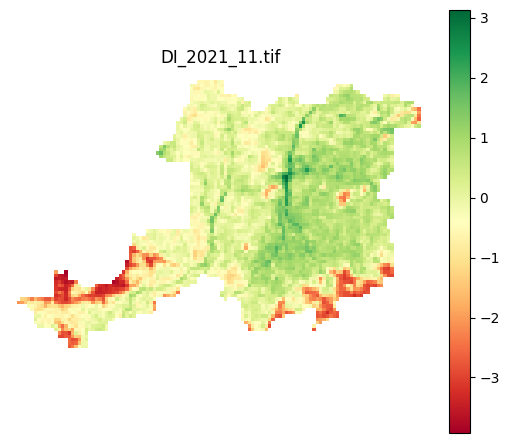

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

# Get yearly DI files
files = sorted(glob.glob(f"{BASE_PATH}/DI_2021_11.tif"))

print("Found yearly maps:", len(files))

n = len(files)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 5 * rows))

for i, f in enumerate(files):

    with rasterio.open(f) as src:
        img = src.read(1).astype("float32")

    # Handle nodata
    img[img == -9999] = np.nan

    # Plot
    plt.subplot(rows, cols, i + 1)

    im = plt.imshow(img, cmap='RdYlGn')  # green = wet, red = drought
    plt.title(os.path.basename(f), fontsize=12)
    plt.axis('off')

    plt.colorbar(im, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import rasterio

BASE_PATH = "/content/drive/MyDrive/mini_project_1"

all_files = glob.glob(f"{BASE_PATH}/DI_*.tif")

di_files = []

for f in all_files:
    name = os.path.basename(f)
    parts = name.replace('DI_', '').replace('.tif', '').split('_')

    # Only keep DI_YYYY_MM
    if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
        di_files.append(f)

di_files = sorted(di_files)

print("Total monthly DI files found:", len(di_files))

rows = []

for p in di_files:

    filename = os.path.basename(p)
    key = filename.replace('DI_', '').replace('.tif', '')

    year, month = key.split('_')

    with rasterio.open(p) as r:
        arr = r.read(1).astype('float32')
        arr[arr == -9999] = np.nan

        mean_di = np.nanmean(arr) if np.any(~np.isnan(arr)) else np.nan

    rows.append({
        'year': int(year),
        'month': int(month),
        'key': key,
        'mean_DI': float(mean_di)
    })

df_di = pd.DataFrame(rows)
df_di = df_di.sort_values(['year', 'month']).reset_index(drop=True)

out_path = f"{BASE_PATH}/DI_timeseries.csv"
df_di.to_csv(out_path, index=False)

print("Saved DI time series at:", out_path)
print(df_di.head())
print("Total months processed:", len(df_di))

Total monthly DI files found: 65
Saved DI time series at: /content/drive/MyDrive/mini_project_1/DI_timeseries.csv
   year  month      key  mean_DI
0  2017      1  2017_01      NaN
1  2017      2  2017_02      NaN
2  2017      3  2017_03      NaN
3  2017      4  2017_04      NaN
4  2017      5  2017_05      NaN
Total months processed: 65
